Note: you may need to restart the kernel to use updated packages.


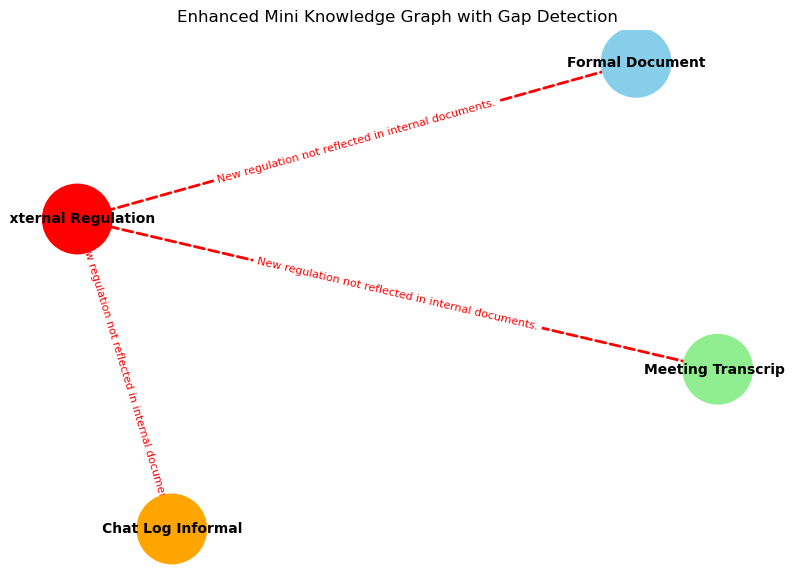


=== Tokenization & Japanese Cultural Sensitivity Demo ===
Formal Document: ['本', 'プロジェクト', 'は', '2024', '年', '4', '月', 'に', '開始', 'さ', 'れ', '、', 'AI', 'システム', 'の', '導入', 'を', '目指し', 'て', 'い'] ...
Meeting Transcript: ['A', ':', ' ', 'この', 'タスク', 'は', 'どう', '進める', '？', ' ', 'B', ':', ' ', 'まあ', '、', '来週', 'まで', 'に', '終わら', 'せる'] ...
Chat Log Informal: ['A', ':', ' ', '了解', 'っす', '！', 'よろしく', 'です', '〜', '。', ' ', 'B', ':', ' ', 'お疲れ様', 'です', '！', '新しい', '資料', '見'] ...
External Regulation: ['2024', '年', '4', '月', '施行', 'の', '新しい', '個人', '情報', '保護', '規制', 'により', '、', '企業', 'は', '顧客', 'データ', 'の', '管理', 'と'] ...

=== Detected Gaps & Narratives ===
New regulation not reflected in internal documents.
New regulation not reflected in internal documents.
New regulation not reflected in internal documents.


In [5]:
# Install libraries if not already
%pip install networkx matplotlib --quiet

import networkx as nx
import matplotlib.pyplot as plt
from janome.tokenizer import Tokenizer
import pandas as pd

# Sample data 
data = [
    {"type": "Formal Document", "content": "本プロジェクトは2024年4月に開始され、AIシステムの導入を目指しています。"},
    {"type": "Meeting Transcript", "content": "A: このタスクはどう進める？ B: まあ、来週までに終わらせるつもりやで。"},
    {"type": "Chat Log Informal", "content": "A: 了解っす！よろしくです〜。 B: お疲れ様です！新しい資料見ました？"},
    {"type": "External Regulation", "content": "2024年4月施行の新しい個人情報保護規制により、企業は顧客データの管理と報告義務を強化する必要があります。"}
]
df = pd.DataFrame(data)

# Tokenizer
tokenizer = Tokenizer()

# Mini Knowledge Graph with Gap Detection
knowledge_graph = {}
gaps = []

# Define node colors by type
node_colors = {
    "Formal Document": "skyblue",
    "Meeting Transcript": "lightgreen",
    "Chat Log Informal": "orange",
    "External Regulation": "red"
}

# Detect gaps and build summaries
for idx, row in df.iterrows():
    doc_type = row['type']
    content = row['content']
    knowledge_graph[doc_type] = content[:50] + "..."
    
    # Gap rule: AIシステム mention but missing launch date
    if "AIシステム" in content and ("年" not in content and "月" not in content):
        gap_summary = f"AIシステム launch date missing in {doc_type}."
        gaps.append((doc_type, "External Regulation", gap_summary))
    
    # Gap rule: New regulation not in internal docs
    if doc_type == "External Regulation" and "規制" in content:
        internal_docs = df[df['type'] != "External Regulation"]['content'].tolist()
        if not any("規制" in doc for doc in internal_docs):
            gap_summary = "New regulation not reflected in internal documents."
            for doc in df[df['type'] != "External Regulation"]['type']:
                gaps.append((doc, "External Regulation", gap_summary))

# Visual Knowledge Graph
G = nx.DiGraph()

# Add nodes
for node in knowledge_graph.keys():
    G.add_node(node)

# Add edges only for detected gaps (highlighted)
for src, tgt, summary in gaps:
    G.add_edge(src, tgt, gap=True, label=summary)

# Draw graph
plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, seed=42)
# Draw nodes with color coding
nx.draw_networkx_nodes(G, pos, node_color=[node_colors[n] for n in G.nodes], node_size=2500)

# Draw edges: red dashed if gap, black solid otherwise
for u, v, data in G.edges(data=True):
    if data.get('gap'):
        nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], edge_color='red', style='dashed', width=2)
    else:
        nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], edge_color='black')

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edge labels for summaries
edge_labels = {(u,v): d['label'] for u,v,d in G.edges(data=True) if d.get('gap')}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

plt.title("Enhanced Mini Knowledge Graph with Gap Detection")
plt.axis('off')
plt.show()

# Print tokenization (cultural sensitivity demo)
print("\n=== Tokenization & Japanese Cultural Sensitivity Demo ===")
for idx, row in df.iterrows():
    tokens = [t.surface for t in tokenizer.tokenize(row['content'])]
    print(f"{row['type']}: {tokens[:20]} ...")  # show first 20 tokens

# Print gap summaries
print("\n=== Detected Gaps & Narratives ===")
for src, tgt, summary in gaps:
    print(summary)


In [ ]:
!pip install janome

